# The Memoryless Property of the Exponential Distribution

The exponential distribution **has no memory**.

If you have already been waiting for time *s*, the distribution of your remaining wait is exactly the same as if you had just started. Past waiting time gives you no information about future waiting time.

Formally:

> **P(X > s + t | X > s) = P(X > t)**   for all s, t ≥ 0

In this notebook we use **λ = ln(2)** — a value chosen so that the survival probabilities at integer times come out as exact powers of 1/2, letting us follow every step of the proof by hand.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from fractions import Fraction
import ipywidgets as widgets
from IPython.display import display

lam = np.log(2)   # λ = ln(2)
print(f'λ = ln(2) ≈ {lam:.6f}')
print(f'Mean waiting time = 1/λ ≈ {1/lam:.4f}')

λ = ln(2) ≈ 0.693147
Mean waiting time = 1/λ ≈ 1.4427


## Why λ = ln(2)?

The PDF of the exponential distribution is:

    f(x) = λ · e^(−λx)    for x ≥ 0

The **survival function** — the probability of waiting *longer* than x — is:

    P(X > x) = e^(−λx)

With λ = ln(2), this simplification occurs:

    P(X > x) = e^(−ln(2)·x) = (e^ln(2))^(−x) = 2^(−x) = 1 / 2^x

At every integer value of x, P(X > x) is exactly 1/2^x — no decimals, no rounding:

| x | P(X > x) |
|---|----------|
| 0 | 1 |
| 1 | 1/2 |
| 2 | 1/4 |
| 3 | 1/8 |
| 4 | 1/16 |

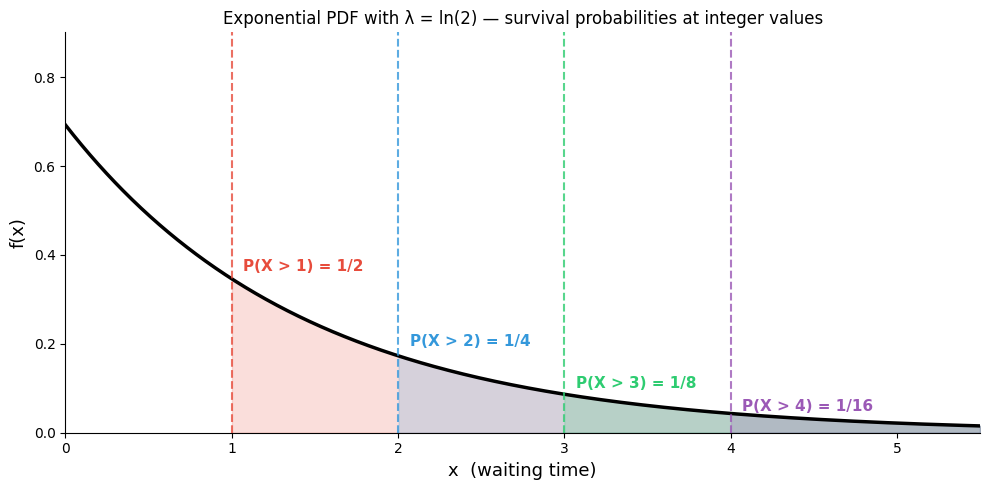

In [2]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.linspace(0, 5.5, 1000)
pdf = lam * np.exp(-lam * x)

ax.plot(x, pdf, 'k-', linewidth=2.5)

colors = ['#E74C3C', '#3498DB', '#2ECC71', '#9B59B6']
for i, xi in enumerate([1, 2, 3, 4]):
    mask = x >= xi
    ax.fill_between(x[mask], 0, pdf[mask], alpha=0.18, color=colors[i])
    ax.axvline(x=xi, color=colors[i], linestyle='--', alpha=0.8, linewidth=1.5)

ax.annotate('P(X > 1) = 1/2',  xy=(1.07, 0.365), fontsize=11, color='#E74C3C', fontweight='bold')
ax.annotate('P(X > 2) = 1/4',  xy=(2.07, 0.195), fontsize=11, color='#3498DB', fontweight='bold')
ax.annotate('P(X > 3) = 1/8',  xy=(3.07, 0.100), fontsize=11, color='#2ECC71', fontweight='bold')
ax.annotate('P(X > 4) = 1/16', xy=(4.07, 0.050), fontsize=11, color='#9B59B6', fontweight='bold')

ax.set_xlabel('x  (waiting time)', fontsize=13)
ax.set_ylabel('f(x)', fontsize=13)
ax.set_title('Exponential PDF with λ = ln(2) — survival probabilities at integer values', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(0, 5.5)
ax.set_ylim(0, lam * 1.3)
ax.set_xticks(range(6))
plt.tight_layout()
plt.show()

## What Does "Memoryless" Mean?

Imagine you are waiting for a bus. The exponential model says: no matter how long you have already been waiting, your remaining wait has the same distribution as when you first arrived.

Waiting 10 minutes and seeing no bus tells you *nothing* about how much longer you will wait. The distribution resets.

Let's make this concrete with s = 1 and t = 1:

| Quantity | Value |
|---|---|
| P(X > 2) | 1/4 |
| P(X > 1) | 1/2 |
| P(X > 2 given X > 1) = P(X > 2) / P(X > 1) | (1/4) ÷ (1/2) = **1/2** |
| P(X > 1) — the target | **1/2** |

The conditional probability equals P(X > 1). The one unit already waited is irrelevant.

The visualization below shows this in three panels. Read left to right.

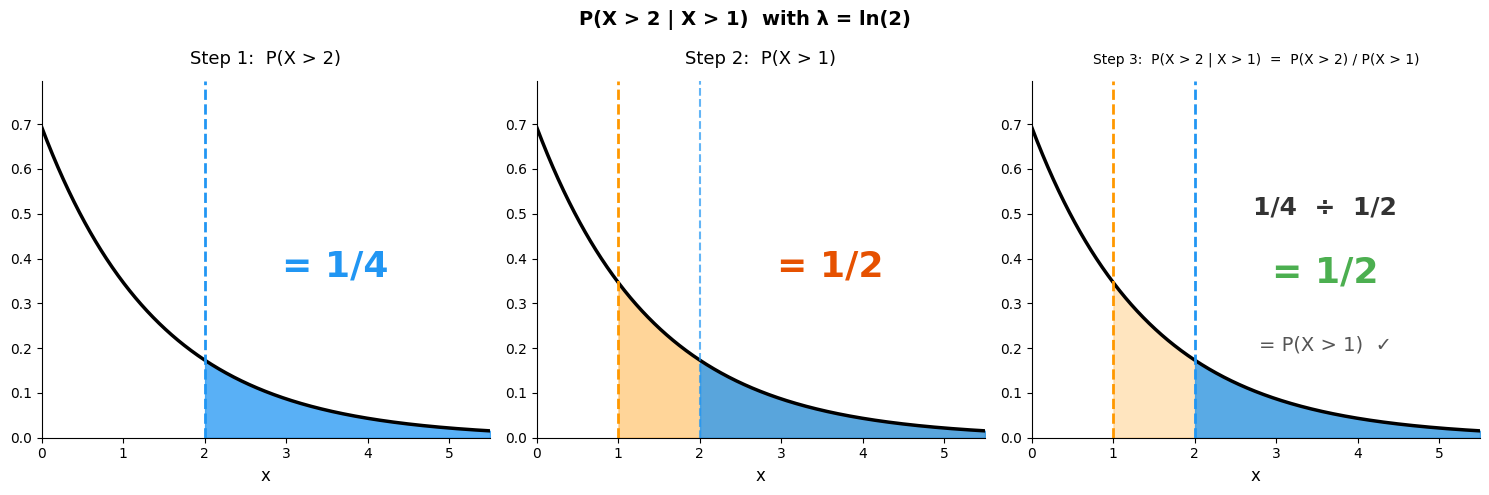

In [3]:
s, t = 1, 1

p_s    = Fraction(1, 2**s)
p_st   = Fraction(1, 2**(s + t))
p_t    = Fraction(1, 2**t)
result = p_st / p_s

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    f'P(X > {s+t} | X > {s})  with λ = ln(2)',
    fontsize=14, fontweight='bold'
)

x = np.linspace(0, 5.5, 1000)
pdf = lam * np.exp(-lam * x)

for ax in axes:
    ax.plot(x, pdf, 'k-', linewidth=2.5)
    ax.set_xlim(0, 5.5)
    ax.set_ylim(0, lam * 1.15)
    ax.set_xticks(range(6))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlabel('x', fontsize=12)

mask_st = x >= s + t
mask_s  = x >= s

# Panel 1: P(X > s+t) — the numerator
axes[0].fill_between(x[mask_st], 0, pdf[mask_st], color='#2196F3', alpha=0.75)
axes[0].axvline(x=s+t, color='#2196F3', linestyle='--', linewidth=2)
axes[0].set_title(f'Step 1:  P(X > {s+t})', fontsize=13, pad=12)
axes[0].text(3.6, lam * 0.52, f'= {p_st}', fontsize=26, ha='center',
             color='#2196F3', fontweight='bold')

# Panel 2: P(X > s) — the denominator, with P(X > s+t) highlighted inside it
axes[1].fill_between(x[mask_s],  0, pdf[mask_s],  color='#FF9800', alpha=0.40)
axes[1].fill_between(x[mask_st], 0, pdf[mask_st], color='#2196F3', alpha=0.75)
axes[1].axvline(x=s,   color='#FF9800', linestyle='--', linewidth=2)
axes[1].axvline(x=s+t, color='#2196F3', linestyle='--', linewidth=1.5, alpha=0.7)
axes[1].set_title(f'Step 2:  P(X > {s})', fontsize=13, pad=12)
axes[1].text(3.6, lam * 0.52, f'= {p_s}', fontsize=26, ha='center',
             color='#E65100', fontweight='bold')

# Panel 3: The ratio = conditional probability
axes[2].fill_between(x[mask_s],  0, pdf[mask_s],  color='#FF9800', alpha=0.25)
axes[2].fill_between(x[mask_st], 0, pdf[mask_st], color='#2196F3', alpha=0.75)
axes[2].axvline(x=s,   color='#FF9800', linestyle='--', linewidth=2)
axes[2].axvline(x=s+t, color='#2196F3', linestyle='--', linewidth=2)
axes[2].set_title(
    f'Step 3:  P(X > {s+t} | X > {s})  =  P(X > {s+t}) / P(X > {s})',
    fontsize=10, pad=12
)
axes[2].text(3.6, lam * 0.72, f'{p_st}  ÷  {p_s}', fontsize=18, ha='center',
             color='#333', fontweight='bold')
axes[2].text(3.6, lam * 0.50, f'= {result}', fontsize=26, ha='center',
             color='#4CAF50', fontweight='bold')
axes[2].text(3.6, lam * 0.28, f'= P(X > {t})  ✓', fontsize=14, ha='center', color='#555')

plt.tight_layout()
plt.show()

## Why It Works: The Algebra

The proof is three lines. We start from the definition of conditional probability:

    P(X > s + t | X > s)

    = P(X > s + t) / P(X > s)          [definition of conditional probability]

    = e^(−λ(s+t))  /  e^(−λs)          [survival function: P(X > x) = e^(−λx)]

    = e^(−λ(s+t) + λs)                  [dividing exponentials = subtracting exponents]

    = e^(−λt)                            [the λs terms cancel]

    = P(X > t)  ✓                        [survival function again]

The key step: the e^(−λs) in the numerator and denominator cancel completely, leaving only e^(−λt).

This works for **any** s and t ≥ 0 — not just integers. The clean fractions at integer values are just the payoff from choosing λ = ln(2).

### What Makes the Exponential Special?

The exponential is the **only continuous distribution** with the memoryless property. This is why it models events at a constant rate — there is no aging. A component with an exponential lifetime is equally likely to fail in the next hour whether it is brand new or has been running for years.

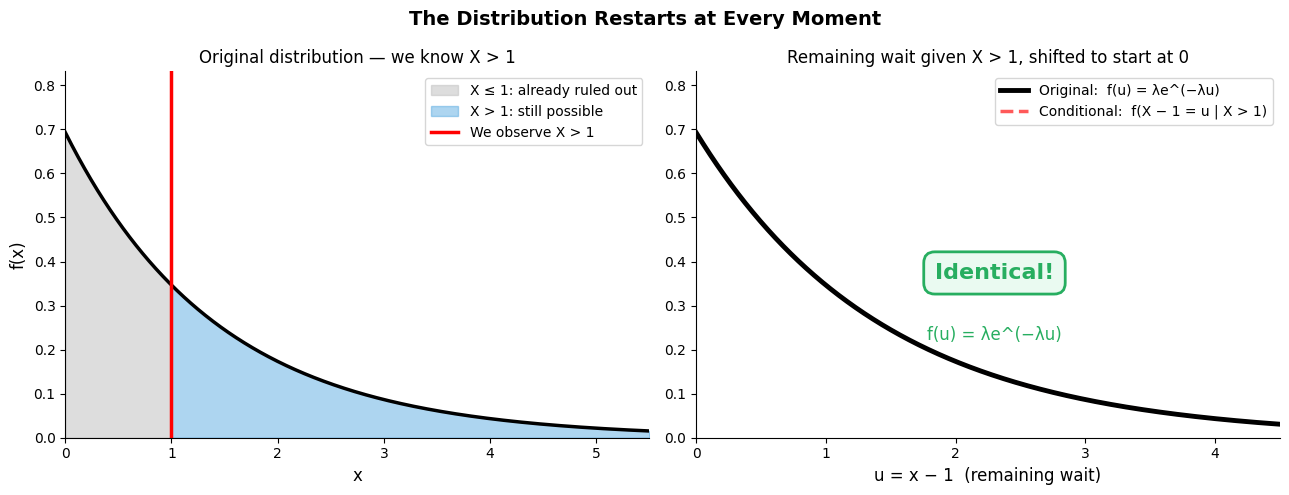

In [4]:
# The 'fresh start' visualization
# Zoom in on the tail X > s and rescale — we get the original distribution back.

s = 1

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('The Distribution Restarts at Every Moment', fontsize=14, fontweight='bold')

x_full   = np.linspace(0, 5.5, 1000)
pdf_full = lam * np.exp(-lam * x_full)

# Left: original PDF with X > s region highlighted
ax = axes[0]
x_before   = x_full[x_full <= s]
x_after    = x_full[x_full >= s]
pdf_before = lam * np.exp(-lam * x_before)
pdf_after  = lam * np.exp(-lam * x_after)

ax.plot(x_full, pdf_full, 'k-', linewidth=2.5)
ax.fill_between(x_before, 0, pdf_before, color='#BDBDBD', alpha=0.5,
                label='X ≤ 1: already ruled out')
ax.fill_between(x_after,  0, pdf_after,  color='#3498DB', alpha=0.4,
                label='X > 1: still possible')
ax.axvline(x=s, color='red', linewidth=2.5, label='We observe X > 1')
ax.set_title(f'Original distribution — we know X > {s}', fontsize=12)
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('f(x)', fontsize=12)
ax.set_xlim(0, 5.5)
ax.set_ylim(0, lam * 1.2)
ax.set_xticks(range(6))
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Right: conditional distribution of U = X - s given X > s
#
# f(u+s) / P(X > s) = lam*e^(-lam*(u+s)) / e^(-lam*s) = lam*e^(-lam*u)
#
# This is IDENTICAL to the original exponential.

u = np.linspace(0, 4.5, 1000)
pdf_original    = lam * np.exp(-lam * u)
pdf_conditional = lam * np.exp(-lam * u)  # the same expression — shown dashed to confirm

ax = axes[1]
ax.plot(u, pdf_original,    'k-',  linewidth=3.5, label='Original:  f(u) = λe^(−λu)',        zorder=3)
ax.plot(u, pdf_conditional, 'r--', linewidth=2.5, alpha=0.65,
        label=f'Conditional:  f(X − {s} = u | X > {s})')
ax.set_title(
    f'Remaining wait given X > {s}, shifted to start at 0',
    fontsize=12
)
ax.set_xlabel(f'u = x − {s}  (remaining wait)', fontsize=12)
ax.set_xlim(0, 4.5)
ax.set_ylim(0, lam * 1.2)
ax.set_xticks(range(5))
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.text(2.3, lam * 0.52, 'Identical!', fontsize=16, ha='center',
        color='#27AE60', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#EAFAF1', edgecolor='#27AE60', linewidth=2))
ax.text(2.3, lam * 0.32, 'f(u) = λe^(−λu)', fontsize=12, ha='center', color='#27AE60')

plt.tight_layout()
plt.show()

## Explore It Yourself

Use the sliders below to pick any integer values for s (how long you have already waited) and t (how much longer you might wait). The three panels update to show the numerator, denominator, and resulting conditional probability — always as exact fractions.

No matter what you pick, the ratio P(X > s+t) / P(X > s) always equals P(X > t).

In [5]:
@widgets.interact(
    s=widgets.IntSlider(min=1, max=4, value=1, description='s (waited):'),
    t=widgets.IntSlider(min=1, max=4, value=1, description='t (more wait):')
)
def explore_memoryless(s=1, t=1):
    p_st   = Fraction(1, 2**(s + t))
    p_s    = Fraction(1, 2**s)
    p_t    = Fraction(1, 2**t)
    result = p_st / p_s

    print(f'P(X > {s+t})            = {p_st}')
    print(f'P(X > {s})              = {p_s}')
    print(f'P(X > {s+t} | X > {s}) = {p_st} / {p_s} = {result}')
    print(f'P(X > {t})              = {p_t}')
    print(f'Equal: {result == p_t}')

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    fig.suptitle(f'P(X > {s+t} | X > {s}) with λ = ln(2)', fontsize=13, fontweight='bold')

    xmax = max(s + t + 3.5, 6.0)
    x    = np.linspace(0, xmax, 1000)
    pdf  = lam * np.exp(-lam * x)
    cx   = (s + t + xmax) / 2

    for ax in axes:
        ax.plot(x, pdf, 'k-', linewidth=2)
        ax.set_xlim(0, xmax)
        ax.set_ylim(0, lam * 1.15)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.set_xlabel('x', fontsize=11)

    mask_st = x >= s + t
    mask_s  = x >= s

    axes[0].fill_between(x[mask_st], 0, pdf[mask_st], color='#2196F3', alpha=0.75)
    axes[0].axvline(x=s+t, color='#2196F3', linestyle='--', linewidth=2)
    axes[0].set_title(f'P(X > {s+t}) = {p_st}', fontsize=12)
    axes[0].text(cx, lam * 0.40, str(p_st), fontsize=24, ha='center',
                 color='#2196F3', fontweight='bold')

    axes[1].fill_between(x[mask_s],  0, pdf[mask_s],  color='#FF9800', alpha=0.40)
    axes[1].fill_between(x[mask_st], 0, pdf[mask_st], color='#2196F3', alpha=0.75)
    axes[1].axvline(x=s,   color='#FF9800', linestyle='--', linewidth=2)
    axes[1].axvline(x=s+t, color='#2196F3', linestyle='--', linewidth=1.5, alpha=0.7)
    axes[1].set_title(f'P(X > {s}) = {p_s}', fontsize=12)
    axes[1].text(cx, lam * 0.40, str(p_s), fontsize=24, ha='center',
                 color='#E65100', fontweight='bold')

    axes[2].fill_between(x[mask_s],  0, pdf[mask_s],  color='#FF9800', alpha=0.25)
    axes[2].fill_between(x[mask_st], 0, pdf[mask_st], color='#2196F3', alpha=0.75)
    axes[2].axvline(x=s,   color='#FF9800', linestyle='--', linewidth=2)
    axes[2].axvline(x=s+t, color='#2196F3', linestyle='--', linewidth=2)
    axes[2].set_title(f'Ratio = {result} = P(X > {t}) ✓', fontsize=12)
    axes[2].text(cx, lam * 0.50, str(result), fontsize=24, ha='center',
                 color='#4CAF50', fontweight='bold')
    axes[2].text(cx, lam * 0.28, f'= P(X > {t})  ✓', fontsize=13, ha='center', color='#555')

    plt.tight_layout()
    plt.show()

interactive(children=(IntSlider(value=1, description='s (waited):', max=4, min=1), IntSlider(value=1, descript…